6.1  Price Prediction

In [1]:
# Load Data
import pandas as pd
import numpy as np

master = pd.read_csv(
    "../data/processed/listing_master.csv"
)

master.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,listing_id,total_reviews,first_review_y,last_review_y,median_price,listing_density,average_rating,host_tenure_years,review_frequency,price_per_bedroom
0,13913,https://www.airbnb.com/rooms/13913,20250914034649,2025-09-16,city scrape,Holiday London DB Room Let-on going,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,13913.0,55.0,2010-08-18,2025-08-21,141.0,5036,4.724966,16.610959,3.311067,70.0
1,15400,https://www.airbnb.com/rooms/15400,20250914034649,2025-09-16,city scrape,Bright Chelsea Apartment. Chelsea!,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,15400.0,97.0,2009-12-21,2025-04-05,225.0,6401,4.714067,16.558904,5.857876,149.0
2,17402,https://www.airbnb.com/rooms/17402,20250914034649,2025-09-16,city scrape,Very Central Modern 3-Bed/2 Bath By Oxford St W1,"You'll have a great time in this beautiful, cl...","Fitzrovia is a very desirable trendy, arty and...",https://a0.muscache.com/pictures/39d5309d-fba7...,67564,...,17402.0,56.0,2011-03-21,2024-02-19,220.0,11385,4.665023,16.476712,3.398736,137.0
3,24328,https://www.airbnb.com/rooms/24328,20250914034649,2025-09-18,previous scrape,Battersea live/work artist house,"Artist house by SW Battersea Park, bright high...","- Battersea is a quiet family area, easy acces...",https://a0.muscache.com/pictures/9194b40f-c627...,41759,...,24328.0,95.0,2010-11-15,2025-07-05,140.0,4965,4.787750,16.745205,5.673266,NaN
4,36274,https://www.airbnb.com/rooms/36274,20250914034649,2025-09-15,city scrape,Bright 1 bedroom apt off brick lane in Shoreditch,*Update June '25- Pump Installed to improve wa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,133271,...,36274.0,15.0,2011-03-20,2025-09-06,127.0,7469,4.680864,16.084932,0.932550,210.0


In [2]:
# Feature Selection
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "review_scores_rating",
    "number_of_reviews",
    "host_tenure_years",
    "price_per_bedroom",
    "room_type",
    "neighbourhood_cleansed"
]

df = master[
    features + ["price"]
].copy()

In [3]:
# Handle Missing Values
df = df.dropna()

In [4]:
#Encode Categories
df = pd.get_dummies(
    df,
    columns=[
        "room_type",
        "neighbourhood_cleansed"
    ],
    drop_first=True
)

In [5]:
#Train/Test Split
from sklearn.model_selection import train_test_split

X = df.drop(
    columns=["price"]
)

y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Model 1: Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
lr_pred = lr.predict(
    X_test
)

In [8]:
# Evaluation Function
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def evaluate(
        name,
        y_true,
        y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    )

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("MAPE:", mape)

In [9]:
evaluate(
    "Linear Regression",
    y_test,
    lr_pred
)

Linear Regression
MAE: 52.41546966035037
RMSE: 191.53932167021267
MAPE: 0.33498979528029554


In [10]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

evaluate(
    "Random Forest",
    y_test,
    rf_pred
)

Random Forest
MAE: 2.3787624346653176
RMSE: 91.49571948669029
MAPE: 0.000900252603180917


In [11]:
# Model 3: Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

evaluate(
    "Gradient Boosting",
    y_test,
    gb_pred
)

Gradient Boosting
MAE: 18.019206950782962
RMSE: 90.50320441234145
MAPE: 0.10332384042359657


In [12]:
# Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print(
    abs(scores.mean())
)

22.339094589180746


In [13]:
# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(15)

price_per_bedroom                                0.970571
bedrooms                                         0.017490
number_of_reviews                                0.003391
beds                                             0.002338
accommodates                                     0.002131
review_scores_rating                             0.001426
host_tenure_years                                0.001168
room_type_Private Room                           0.000444
neighbourhood_cleansed_Islington                 0.000281
neighbourhood_cleansed_Lambeth                   0.000220
neighbourhood_cleansed_Camden                    0.000185
neighbourhood_cleansed_Kensington and Chelsea    0.000086
neighbourhood_cleansed_Hackney                   0.000072
neighbourhood_cleansed_Enfield                   0.000033
neighbourhood_cleansed_Westminster               0.000028
dtype: float64

<Axes: >

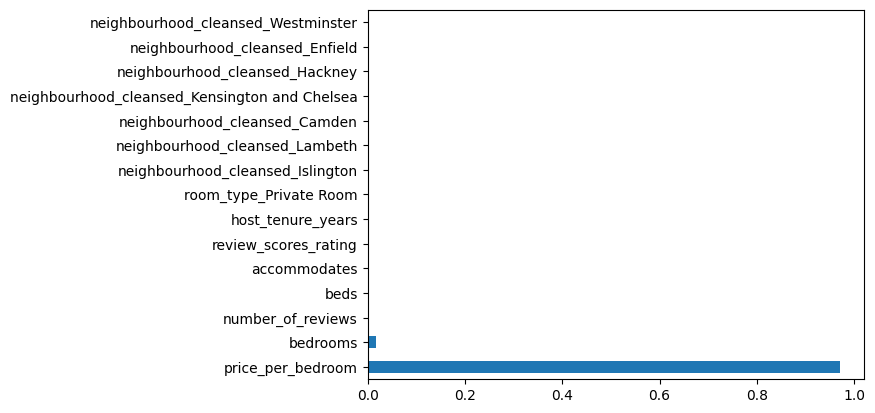

In [14]:
importance.sort_values(
    ascending=False
).head(15).plot(
    kind="barh"
)

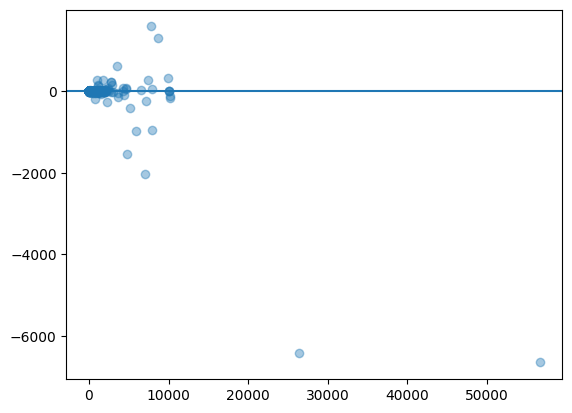

In [16]:
# Residual Analysis

import matplotlib.pyplot as plt
residuals = y_test - rf_pred

plt.scatter(
    rf_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0
)

plt.show()

6.3  Host & Listing Segmentation 

In [17]:
# Clustering Dataset
cluster_features = [
    "price",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "host_tenure_years"
]

cluster_df = master[
    cluster_features
].dropna()

In [18]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(
    cluster_df
)

In [19]:
# KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled
)

cluster_df["cluster"] = clusters

In [20]:
# Profile Segments
cluster_df.groupby(
    "cluster"
).mean()

,price,review_scores_rating,number_of_reviews,availability_365,host_tenure_years
cluster,,,,,
0,2.333314e+02,4.547617,10.075263,286.530318,3.584592
1,2.198829e+02,4.789869,48.119286,294.109449,10.818878
2,1.859027e+02,4.779776,24.241373,76.245025,8.791021
3,1.085147e+06,4.830000,0.000000,364.000000,1.265753


In [21]:
# Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled,
    clusters
)

print(score)

0.28519010632940006


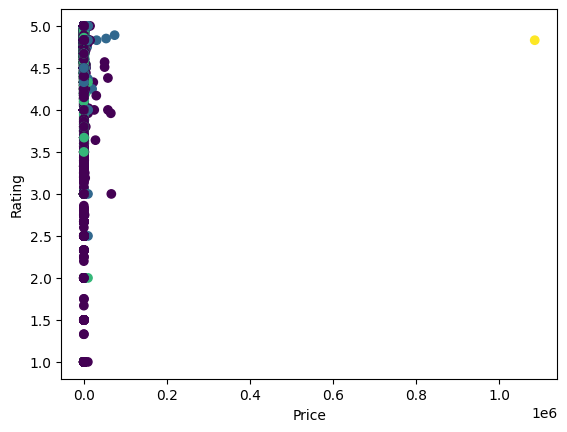

In [22]:
# Visualization
plt.scatter(
    cluster_df["price"],
    cluster_df["review_scores_rating"],
    c=cluster_df["cluster"]
)

plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()